In [1]:
import os
os.makedirs('data', exist_ok=True)

In [2]:
import os
import shutil
import numpy as np
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.layers import (
    Input,
    Add,
    Dropout,
    Dense,
    Activation,
    ZeroPadding2D,
    BatchNormalization,
    Flatten,
    Conv2D,
    AveragePooling2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from IPython.display import SVG
from matplotlib.pyplot import imshow
%matplotlib inline


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Path to dataset files: /kaggle/input/flowers-recognition


In [4]:
# Where all dataset is there
# If you downloaded via kagglehub in the previous cell, `path` points to the dataset root.
# This dataset's images are typically under a `flowers/` subfolder.

data_dir = os.path.join(path, "flowers")

# Training data dir
training_dir = os.path.join('data', 'Train')

# Test data dir
testing_dir = os.path.join('data', 'Test')

# Ratio of training and testing data
train_test_ratio = 0.8


def split_dataset_into_test_and_train_sets(
    all_data_dir=data_dir,
    training_data_dir=training_dir,
    testing_data_dir=testing_dir,
    train_test_ratio=0.8,
):
    # Create testing and training directories
    os.makedirs(training_data_dir, exist_ok=True)
    os.makedirs(testing_data_dir, exist_ok=True)

    num_training_files = 0
    num_testing_files = 0

    for subdir, dirs, files in os.walk(all_data_dir):
        category_name = os.path.basename(subdir)

        if category_name == os.path.basename(all_data_dir):
            continue

        training_data_category_dir = os.path.join(training_data_dir, category_name)
        testing_data_category_dir = os.path.join(testing_data_dir, category_name)

        # creating subdir for each sub category
        os.makedirs(training_data_category_dir, exist_ok=True)
        os.makedirs(testing_data_category_dir, exist_ok=True)

        file_list = glob.glob(os.path.join(subdir, '*.jpg'))

        print(str(category_name) + ' has ' + str(len(file_list)) + ' images')
        random_set = np.random.permutation(file_list)

        # copy percentage of data from each category to train and test directory
        train_list = random_set[: round(len(random_set) * train_test_ratio)]
        test_list = random_set[-round(len(random_set) * (1 - train_test_ratio)) :]

        for lists in train_list :
            shutil.copy(lists, training_data_dir + '/' + category_name + '/' )
            num_training_files += 1

        for p in test_list:
            shutil.copy(p, testing_data_category_dir)
            num_testing_files += 1

    print("Processed " + str(num_training_files) + " training files.")
    print("Processed " + str(num_testing_files) + " testing files.")

In [5]:
split_dataset_into_test_and_train_sets()

dandelion has 1052 images
daisy has 764 images
sunflower has 733 images
tulip has 984 images
rose has 784 images
Processed 3453 training files.
Processed 864 testing files.


In [6]:
# Number of classes in dataset
num_classes = 5

def get_model():
    # Get base model
    # Here we are using ResNet50 as base model
    base_model = ResNet50(weights='imagenet', include_top=False)

    # As we are using ResNet model only for feature extraction and not adjusting the weights
    # we freeze the layers in base model
    for layer in base_model.layers:
        layer.trainable = False

    # Get base model output
    base_model_ouput = base_model.output

    # Adding our own layer
    x = GlobalAveragePooling2D()(base_model_ouput)
    # Adding fully connected layer
    x = Dense(512, activation='relu')(x)
    x = Dense(num_classes, activation='softmax', name='fcnew')(x)

    model = Model(inputs=base_model.input, outputs=x)
    return model

In [7]:
# Get the model
model = get_model()
# Compile it
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
# Summary of model
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,472 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, None,      │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, None,      │          0 │ conv2_block1_2_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, None,      │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, None,      │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, None,      │      1,024 │ conv2_block1_3_c

 Total params: 24,639,365 (93.99 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
# TF 2.19 / Keras 3-friendly input pipeline

image_size = (224, 224)
batch_size = 64

train_ds = keras.utils.image_dataset_from_directory(
    training_dir,
    label_mode="categorical",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
)
val_ds = keras.utils.image_dataset_from_directory(
    testing_dir,
    label_mode="categorical",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
)

# Data augmentation (train only)
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

AUTOTUNE = tf.data.AUTOTUNE

def _augment_and_preprocess(images, labels):
    images = tf.cast(images, tf.float32)
    images = data_augmentation(images, training=True)
    images = preprocess_input(images)
    return images, labels

def _preprocess(images, labels):
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels

train_ds = train_ds.map(_augment_and_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds.map(_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

Found 3453 files belonging to 5 classes.
Found 864 files belonging to 5 classes.


In [9]:
# Training the fully connected layer for initial epochs
epochs = 5

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1,
)

Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6242 - loss: 1.0035 - val_accuracy: 0.8519 - val_loss: 0.4264
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 754ms/step - accuracy: 0.8576 - loss: 0.4223 - val_accuracy: 0.8762 - val_loss: 0.3464
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 747ms/step - accuracy: 0.8814 - loss: 0.3487 - val_accuracy: 0.8924 - val_loss: 0.3233
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 742ms/step - accuracy: 0.8959 - loss: 0.2982 - val_accuracy: 0.8924 - val_loss: 0.3010
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 750ms/step - accuracy: 0.9169 - loss: 0.2790 - val_accuracy: 0.9051 - val_loss: 0.2795


In [10]:
# More fine tuning the model
# Training the model after ~140 layers
# Generally ResNet is good at extracting lower level features so we are not fine tuning initial layers
epochs = 10

split_at = 140
for layer in model.layers[:split_at]:
    layer.trainable = False
for layer in model.layers[split_at:]:
    layer.trainable = True

# Choosing lower learning rate for fine-tuning
# learning rate is generally 10-1000 times lower than normal learning rate, if we are fine tuning the initial layers
sgd = optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1,
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8722 - loss: 0.4061 - val_accuracy: 0.8981 - val_loss: 0.2888
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 759ms/step - accuracy: 0.9321 - loss: 0.2276 - val_accuracy: 0.9132 - val_loss: 0.2461
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 754ms/step - accuracy: 0.9479 - loss: 0.1700 - val_accuracy: 0.9213 - val_loss: 0.2295
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 750ms/step - accuracy: 0.9620 - loss: 0.1300 - val_accuracy: 0.9225 - val_loss: 0.2222
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 774ms/step - accuracy: 0.9748 - loss: 0.1015 - val_accuracy: 0.9248 - val_loss: 0.2149
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 747ms/step - accuracy: 0.9778 - loss: 0.0904 - val_accuracy: 0.9259 - val_loss: 0.2124
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 755ms/step - accuracy: 0.9865 - loss: 0.0641 - val_accuracy: 0.9282 - val_loss: 0.2090
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 756ms/step - accuracy: 0.9824 - loss: 0.0615 - val_accurac

Training complete

Sample image: data/sample_flower.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted class: daisy
Confidence: 0.5684


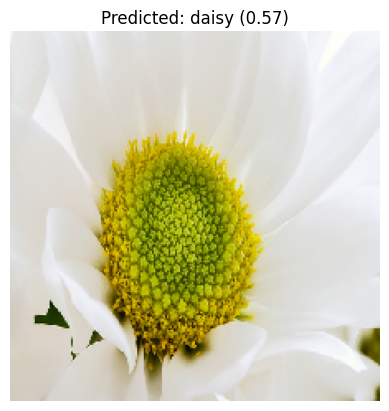

In [14]:
import random, matplotlib.pyplot as plt
import os # Import os module to list directories

# Get class names
class_names = sorted(os.listdir(testing_dir))

sample_image_path = "data/sample_flower.jpg" # Changed backslash to forward slash for compatibility
# Select a random image from the test
print(f"Sample image: {sample_image_path}")

# Load and preprocess the image
img = keras.utils.load_img(sample_image_path, target_size=image_size)
img_array = keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions)

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.4f}")

# Display the image
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence:.2f})")
plt.axis('off')
plt.show()

The fine-tuned model predicts the class perfectly!